In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
path = "/content/gdrive/MyDrive/Colab Notebooks/"
import sys; sys.path.append(path+'lib')
from variable_print import p,ps,pst

In [ ]:
%%capture
!pip install --upgrade gymnasium[classic_control]

# DDQN(Double DQN)

# Neural Network 적용

In [ ]:
import numpy as np
from collections import deque
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchsummary as summary

import time
import random

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

import warnings
warnings.filterwarnings("ignore")

In [ ]:
import gymnasium as gym
env = gym.make("CartPole-v1",render_mode="rgb_array")

n_state = env.observation_space.shape[0]
n_action = env.action_space.n

print(f"State dimension: {n_state}")
print(f"Action dimension: {n_action}")

State dimension: 4
Action dimension: 2


# Network

### Neural Network

In [ ]:
hidden_units=256

class QNetwork(nn.Module):
    def __init__(self, state_size, action_size):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(state_size, hidden_units)
        self.fc2 = nn.Linear(hidden_units, hidden_units)
        self.fc3 = nn.Linear(hidden_units, action_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

model = QNetwork(n_state,n_action).to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))
summary.summary(model, input_size=(4,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 256]           1,280
            Linear-2                  [-1, 256]          65,792
            Linear-3                    [-1, 2]             514
Total params: 67,586
Trainable params: 67,586
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.26
Estimated Total Size (MB): 0.26
----------------------------------------------------------------


# DDQNAgent

In [ ]:
class DDQNAgent:
    def __init__(self):
        self.q_network = QNetwork(n_state, n_action)
        self.target_network = QNetwork(n_state, n_action)
        self.update_target_network(tau=1.0) # 초기에는 가중치를 완전히 복사
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=0.0005)

        self.memory = deque(maxlen=buffer_size)
        self.epsilon = eps_start

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def get_action(self, state, epsilon):
        if np.random.random() < epsilon:
            return env.action_space.sample() # Exploration
        else:
            with torch.no_grad():
                state_tensor = torch.FloatTensor(state).unsqueeze(0)
                q_values = self.q_network(state_tensor)
                return torch.argmax(q_values).item() # Exploitation

    def learn(self):
        if len(self.memory) < batch_size:
            return 0.0

        minibatch = random.sample(self.memory, batch_size)
        states, actions, rewards, next_states, dones = map(np.array, zip(*minibatch))

        states = torch.FloatTensor(states)
        actions = torch.LongTensor(actions).unsqueeze(1)
        rewards = torch.FloatTensor(rewards).unsqueeze(1)
        next_states = torch.FloatTensor(next_states)
        dones = torch.FloatTensor(dones).unsqueeze(1)

        # 현재 Q-value 계산
        current_q_values = self.q_network(states).gather(1, actions)

        # DDQN을 위한 Target Q-value 계산
        with torch.no_grad():
            # 다음 행동은 메인 네트워크에서 선택
            next_actions = self.q_network(next_states).argmax(1, keepdim=True)
            # 해당 행동의 가치는 타겟 네트워크에서 평가
            next_q_values = self.target_network(next_states).gather(1, next_actions)

            target_q_values = rewards + (1 - dones) * gamma * next_q_values

        # 손실 계산 및 모델 업데이트
        loss = F.mse_loss(current_q_values, target_q_values)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return loss.item()

    def update_target_network(self, tau):
        for target_param, param in zip(self.target_network.parameters(), self.q_network.parameters()):
            target_param.data.copy_(tau * param.data + (1.0 - tau) * target_param.data)

    def save_model(self, path):
        torch.save(self.q_network.state_dict(), path)

    def load_model(self, path):
        self.q_network.load_state_dict(torch.load(path))
        self.q_network.eval()


## Training

In [ ]:
# Epsilon-Greedy 정책 관련
eps_start = 0.5
eps_decay = 0.8
down_steps = 3
n_episode = 75

def eps_schedule(step, plot=False):
    eps_decay_step = n_episode // down_steps
    epsilon = max(0.01, eps_start * eps_decay**(step // eps_decay_step))
    return epsilon

In [ ]:
%%time
learning_rate = 0.0005
gamma = 0.95
buffer_size = 20000
batch_size = 128
tau = 0.01

agent = DDQNAgent()
scores = [0]
mean_scores = []
losses = []
model_path = "ddqn_cartpole_best.pth"
max_steps = 170

print("학습을 시작합니다...")
for i in range(n_episode):
    s, info = env.reset()
    score = loss = 0

    while True:
        epsilon = eps_schedule(i)
        a = agent.get_action(s, epsilon)
        ns, r, terminated, truncated, info = env.step(a)
        done = terminated or truncated

        if done and score < max_steps: r -= 100

        agent.remember(s, a, r, ns, done)

        if len(agent.memory) > batch_size:
            loss = agent.learn()
            agent.update_target_network(tau)

        s = ns
        score += r
        if done: break

    score = score if score > max_steps else score + 100
    scores.append(score)
    mean_score = np.mean(scores[-10:])
    mean_scores.append(mean_score)
    max_steps = mean_score * 1.5

    print(f'Eps.[{i:03d}], score:{score}, Mean score:{mean_score:.2f}, loss:{loss:.2f}, Epsilon:{epsilon:.2f}')

    if mean_score > 450:
        print("목표 점수에 도달하여 학습을 조기 종료합니다.")
        break

agent.save_model(model_path)
env.close()
print("학습 종료!")

# Wall time: 19.5 s

학습을 시작합니다...
Eps.[000], score:10.0, Mean score:5.00, loss:0.00, Epsilon:0.50
Eps.[001], score:13.0, Mean score:7.67, loss:0.00, Epsilon:0.50
Eps.[002], score:16.0, Mean score:9.75, loss:0.00, Epsilon:0.50
Eps.[003], score:31.0, Mean score:14.00, loss:0.00, Epsilon:0.50
Eps.[004], score:14.0, Mean score:14.00, loss:0.00, Epsilon:0.50
Eps.[005], score:12.0, Mean score:13.71, loss:0.00, Epsilon:0.50
Eps.[006], score:11.0, Mean score:13.38, loss:0.00, Epsilon:0.50
Eps.[007], score:12.0, Mean score:13.22, loss:0.00, Epsilon:0.50
Eps.[008], score:19.0, Mean score:13.80, loss:377.81, Epsilon:0.50
Eps.[009], score:14.0, Mean score:15.20, loss:442.71, Epsilon:0.50
Eps.[010], score:11.0, Mean score:15.30, loss:575.80, Epsilon:0.50
Eps.[011], score:10.0, Mean score:15.00, loss:620.76, Epsilon:0.50
Eps.[012], score:16.0, Mean score:15.00, loss:387.34, Epsilon:0.50
Eps.[013], score:11.0, Mean score:13.00, loss:443.40, Epsilon:0.50
Eps.[014], score:9.0, Mean score:12.50, loss:385.23, Epsilon:0.50
Ep

# Evaluation  

In [ ]:
condition = f'hidden_units:{hidden_units}, eps_start:{eps_start}, '+\
            f'eps_start:{eps_start}, eps_decay:{eps_decay}, tau:{tau}'

plt.figure(figsize=(5, 3))
plt.plot(scores, label='Score')
plt.plot(mean_scores, label='Mean Score')
plt.title(f"DDQN scores for CartPole\n {condition}")
plt.ylabel('Score')
plt.xlabel('Episode')
plt.grid()
plt.legend()
plt.show()

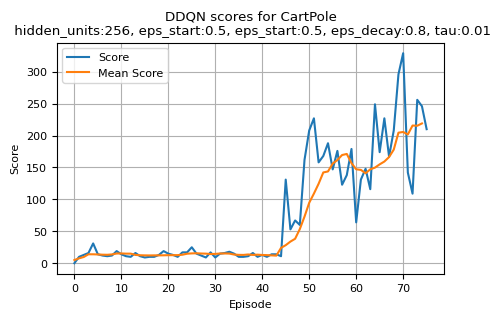

164.0


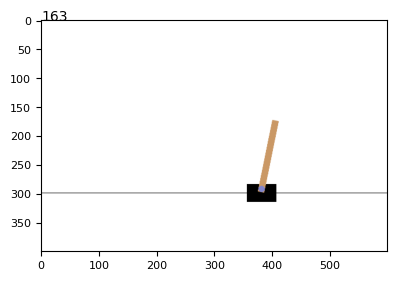

In [ ]:
from IPython.display import clear_output

state,_ = env.reset()
action_l = []
rewards = 0
for i in range(500): # while True:
    plt.figure(figsize=(5,3))
    plt.imshow(env.render())
    plt.text(0,0,str(i),fontsize=10)
    action = agent.get_action(state, epsilon)
    state, reward, done , info, _ = env.step(action)
    clear_output(wait=True)
    rewards += reward
    if done: break;
    else: plt.show()
print(rewards)
env.close()

In [ ]:
%%time
%%capture
!pip install pyvirtualdisplay
!sudo apt-get update
!sudo apt-get install python-opengl
!sudo apt-get install -f
!sudo apt-get upgrade --fix-missing
!sudo apt-get install xvfb

CPU times: user 2 s, sys: 340 ms, total: 2.34 s
Wall time: 50.6 s


In [ ]:
from render import  show_video, wrap_env, render_as_image

In [ ]:
from pyvirtualdisplay import Display
display = Display(visible=0, size=(400, 300))
display.start()

In [ ]:
env = wrap_env(env, path=path, name_prefix="DDQN-cartpole")

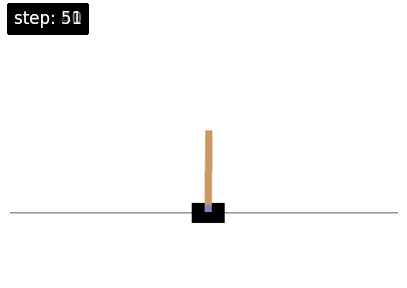

In [ ]:
state, _ = env.reset()
cnt = 0
while True:
    render_as_image(env,step=cnt)
    action = agent.get_action(state, epsilon)
    state, reward, done, info, _ = env.step(action)
    if done or cnt > 50:  break;
    cnt += 1
env.close()

In [ ]:
show_video(path=path,name_prefix='DDQN-cartpole')

/content/gdrive/MyDrive/Colab Notebooks/video/DDQN-cartpole-episode-0.mp4
